# Name: Sydney Golden
# Group 2

#Part 1

##I. Clearly state the question in detail and explain how it is useful or related to the overall project topic.


*“Can PCA reveal meaningful structure and patterns of variation among data science job roles based on salary in USD and experience level?”*

Our question will provide useful insights into our project because we can see how the combination of the variables of experience level and salary in usd interplay into variations of  job titles.

This analysis is additionally useful for our project because it helps us understand deeper aspects of what ends up impacting the kinds of job titles individuals have in the data science field. It provides a more holistic perspective instead of honing in on just one response variable.


In [249]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [250]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [251]:
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from ISLP.cluster import compute_linkage

In [252]:
# Load the merged dataset
df = pd.read_csv("https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/refs/heads/main/data/ds_salaries_clean.csv")
print("Dataset Preview:")
df.head()

Dataset Preview:


,ID,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,1,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
2,3,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3,4,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
4,5,2020,EN,FT,Data Scientist,43200,EUR,49268,DE,0,DE,S


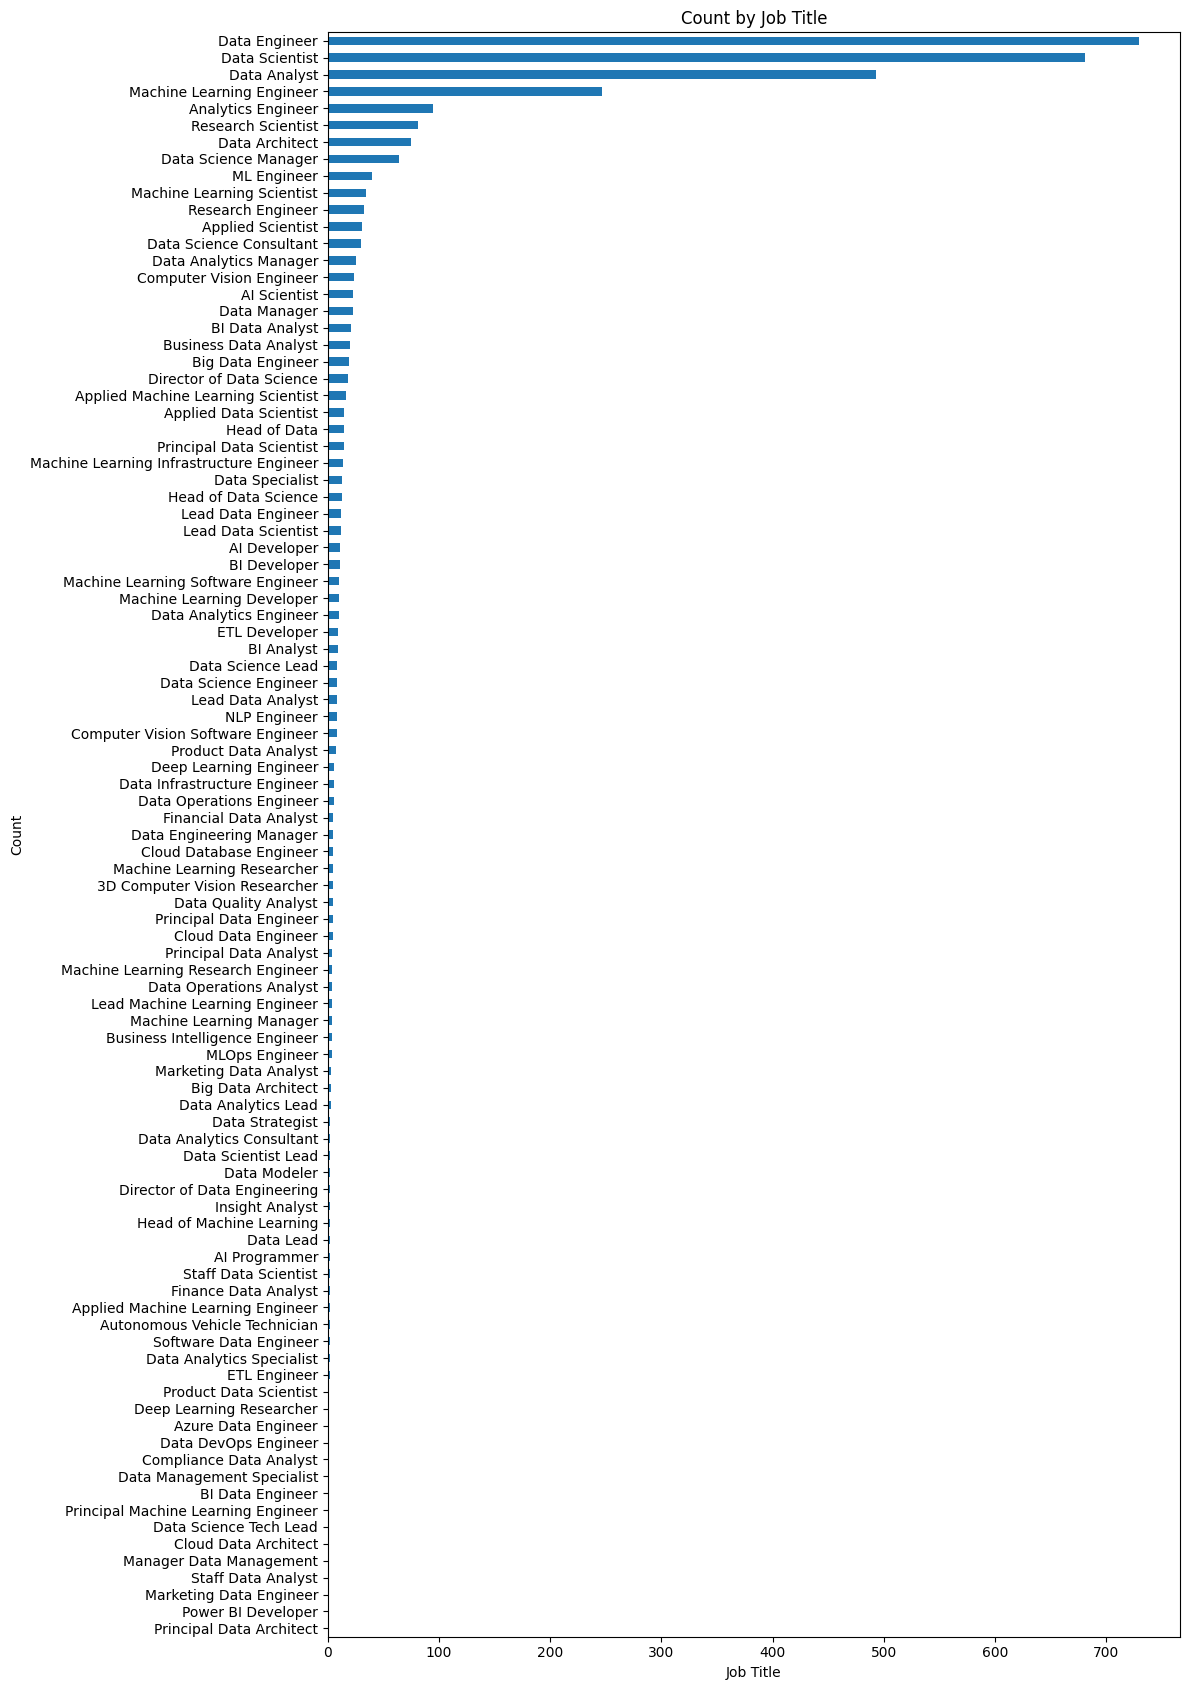

In [253]:
# Plot 2.1: Count by Job Title
plt.figure(figsize=(12, 17))
df['job_title'].value_counts().sort_values(ascending=True).plot(kind='barh')
plt.title('Count by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

##II. Prepare an appropriate dataset for PCA. List and explain the variables included in the analysis and why they are appropriate. If variables are measured on different scales, standardize the variables before applying PCA.

**Job Titles**: We limited our job titles to these roles based on a value count of the top 10 most prominent job titles. We cleaned some of our data to standardized job titles (i.e. Machine Learning Engineer vs. ML Engineer)

Data Scientist

Data Analyst

Data Engineer

Machine Learning Engineer

Analytics Engineer

Research Scientist

Data Architect

Data Science Manager

Machine Learning Scientist

Research Engineer


**Salary (in USD)** :

Salary in usd is a numeric variable. Even though it is strongly correlated with the salary variable, it is still worth exploring this relationship in this context, and also since we have a limited number of numeric variables in our dataset. It will be interesting also for understanding the inner workings of PCA, as we already assume salary in USD will be related to salary.

**Experience Level**:

With a limited amount of quantitative data, we transformed experience level into ordinal variables to provide more insight. Here, we are making the assumption that there is an equal amount of distance between each level, which include:
EN': 1, 'MI': 2, 'SE': 3, 'EX': 4

*  Entry (EN): 1
*  Mid Level (MI): 2
*  Senior (SE): 3
*  Executive (EX): 4





**Salary Currency**:

Ultimately used as a filter for our overall data, but not used as a variable in the PCA.


**Prepping the dataset**

In [254]:
df['job_title'].value_counts().head(11)

,count
job_title,
Data Engineer,730
Data Scientist,681
Data Analyst,493
Machine Learning Engineer,247
Analytics Engineer,95
Research Scientist,81
Data Architect,75
Data Science Manager,64
ML Engineer,40


In [255]:
print(df['experience_level'].unique())
print(df['experience_level'].value_counts())

['EX' 'MI' 'EN' 'SE']
experience_level
SE    1834
MI     877
EN     358
EX     122
Name: count, dtype: int64


In [256]:
# Prepping the dataset
clean = df.copy()
clean = clean[['job_title','salary_in_usd', 'experience_level', 'salary_currency']]
clean['job_title'] = clean['job_title'].replace({'ML Engineer': 'Machine Learning Engineer'})

In [257]:
clean_2 = clean.loc[(clean['salary_currency'] == 'USD') | (clean['salary_currency'] == 'CAD') | (clean['salary_currency'] == 'GBP')]
clean_2 = clean_2.reset_index(drop=True)
clean_2 = clean_2[['job_title','salary_in_usd', 'experience_level']]

In [258]:
top_10_titles = clean_2['job_title'].value_counts().nlargest(10).index
clean_3 = clean_2[clean_2['job_title'].isin(top_10_titles)].reset_index(drop=True)
clean_3

,job_title,salary_in_usd,experience_level
0,Research Scientist,450000,MI
1,Machine Learning Engineer,250000,EN
2,Data Analyst,10000,EN
3,Machine Learning Engineer,138000,EN
4,Data Scientist,45760,MI
...,...,...,...
2255,Data Engineer,182000,SE
2256,Machine Learning Engineer,261500,SE
2257,Machine Learning Engineer,134500,SE
2258,Data Scientist,130000,MI


In [259]:
# Mapping experience levels to labeled numeric order, then one-hot encoding for biplot vectors
experience_order = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}
clean_3['experience_level_ordinal'] = clean_2.loc[clean_3.index, 'experience_level'].map(experience_order)

# One-hot encode job_title and experience_level for separate biplot vectors
clean_3_encoded = pd.get_dummies(clean_3, columns=['job_title']).drop(columns=['salary_in_usd', 'experience_level'])
clean_3_encoded = pd.get_dummies(clean_3_encoded, columns=['experience_level_ordinal'], prefix='exp')
clean_3_encoded = clean_3_encoded.rename(columns={'exp_1': 'EN', 'exp_2': 'MI', 'exp_3': 'SE', 'exp_4': 'EX'})

In [260]:
clean_3_encoded.var()

,0
job_title_Analytics Engineer,0.040286
job_title_Data Analyst,0.161130
job_title_Data Architect,0.032099
job_title_Data Engineer,0.204605
job_title_Data Science Manager,0.025436
job_title_Data Scientist,0.185800
job_title_Machine Learning Engineer,0.094261
job_title_Machine Learning Scientist,0.014395
job_title_Research Engineer,0.013535
job_title_Research Scientist,0.029196


In [261]:
clean_3_encoded.mean()

,0
job_title_Analytics Engineer,0.042035
job_title_Data Analyst,0.201770
job_title_Data Architect,0.033186
job_title_Data Engineer,0.286726
job_title_Data Science Manager,0.026106
job_title_Data Scientist,0.246460
job_title_Machine Learning Engineer,0.105310
job_title_Machine Learning Scientist,0.014602
job_title_Research Engineer,0.013717
job_title_Research Scientist,0.030088


In [262]:
# Scale the data
scaler = StandardScaler(with_std=True,
                        with_mean=True)
scaled = pd.DataFrame(scaler.fit_transform(clean_3_encoded),
                      columns=clean_3_encoded.columns)

In [263]:
pcaUS = PCA()

In [264]:
# Fit PCA

pcaUS.fit(scaled)

PCA()

In [265]:
pcaUS.mean_

array([ 2.35799580e-17, -4.55879189e-17, -3.92999301e-17, -6.99538755e-17,
       -3.45839385e-17,  4.40159217e-17,  2.98679469e-17, -2.51519552e-17,
       -1.88639664e-17,  9.43198322e-18, -5.65918993e-17,  2.51519552e-17,
        1.19471787e-16, -2.35799580e-17])

In [266]:
scores = pcaUS.transform(scaled)

In [267]:
pcaUS.components_

array([[-1.60523181e-02, -4.02934170e-02, -5.54460908e-02,
         3.93034465e-02,  1.79870603e-02,  6.46826892e-02,
        -2.87284071e-02, -2.34045126e-02, -3.81886353e-03,
        -4.17023874e-02, -2.33180467e-01, -6.05371486e-01,
         7.37440936e-01, -1.45597678e-01],
       [-2.33113996e-02, -1.31518007e-01, -2.44520982e-02,
         7.75603495e-01, -1.32926018e-02, -6.07468201e-01,
        -6.61368661e-02, -6.25927379e-03, -1.44108859e-02,
        -1.33386028e-02,  1.01661938e-03, -2.60399053e-02,
        -7.58739581e-03,  7.26020851e-02],
       [ 4.38734958e-02,  7.52706587e-01,  8.63492785e-03,
        -2.83763873e-01,  5.71625805e-02, -4.93243464e-01,
         7.41590792e-03,  4.45624549e-02,  1.05897535e-02,
         6.14303479e-02, -5.88184800e-02, -1.28907169e-01,
         3.53596112e-02,  2.77670893e-01],
       [-1.11671837e-01,  1.32445986e-01, -1.72398002e-01,
         1.20337014e-01, -2.35106724e-02,  2.30413630e-01,
        -4.16058535e-01,  1.05908969e-01, -4.

##III. Create a biplot and interpret in the context of your dataset. Discuss the observations, loading vectors, and any visible patterns among the predictors and observations.

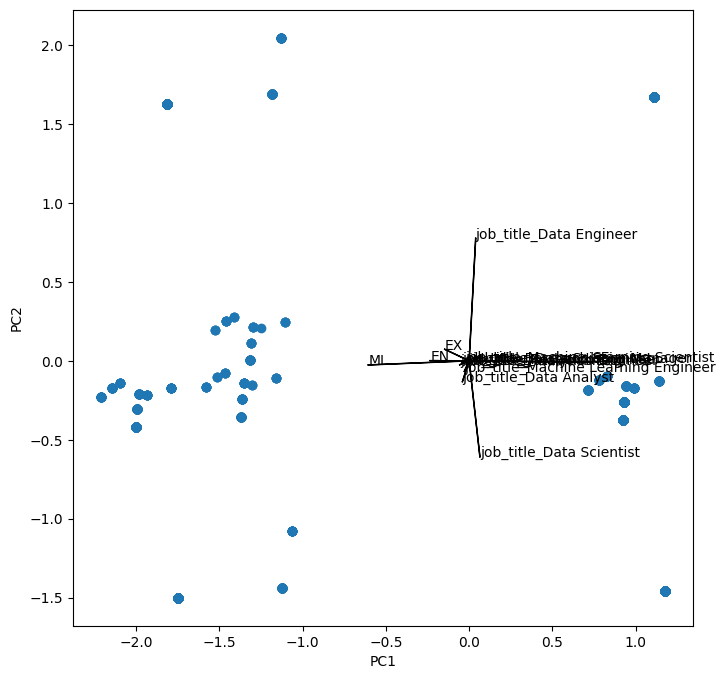

In [268]:
# Creating biplot
i, j = 0, 1 # which components
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaUS.components_.shape[1]):
    ax.arrow(0, 0, pcaUS.components_[i,k], pcaUS.components_[j,k])
    ax.text(pcaUS.components_[i,k],
            pcaUS.components_[j,k],
            scaled.columns[k])

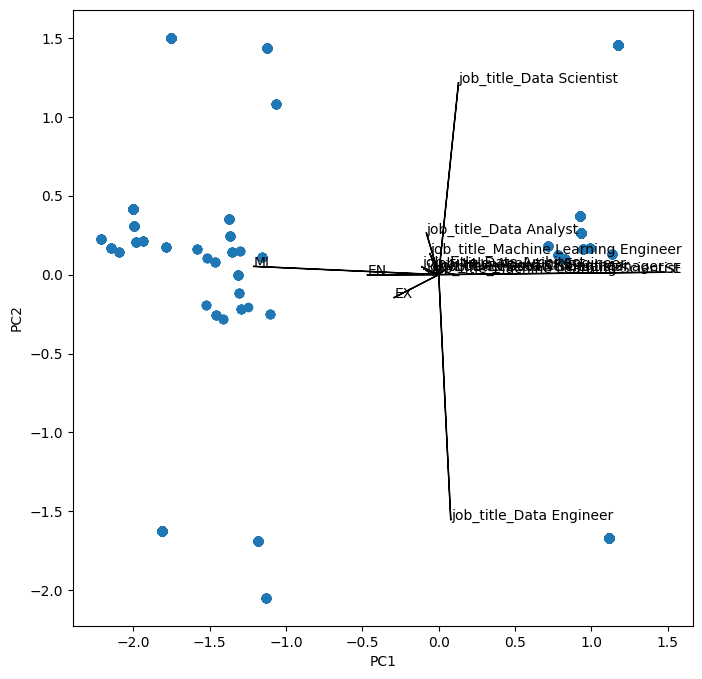

In [269]:
scale_arrow = s_ = 2
scores[:,1] *= -1
pcaUS.components_[1] *= -1 # flip the y-axis
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaUS.components_.shape[1]):
    ax.arrow(0, 0, s_*pcaUS.components_[i,k], s_*pcaUS.components_[j,k])
    ax.text(s_*pcaUS.components_[i,k],
            s_*pcaUS.components_[j,k],
            scaled.columns[k])


##Defined plot

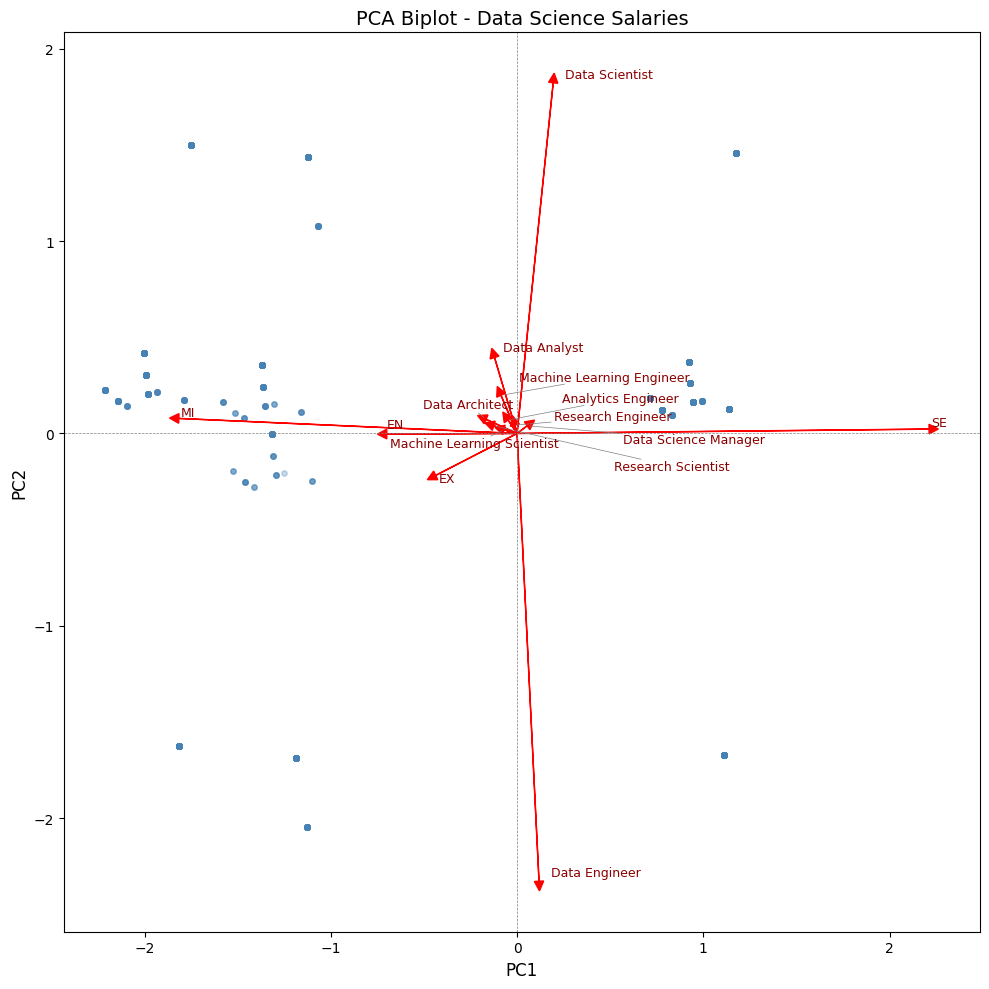

In [270]:
#Creating a clearer plot
from adjustText import adjust_text

i, j = 0, 1
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot scores
ax.scatter(scores[:, 0], scores[:, 1], alpha=0.3, s=15, color='steelblue')

# Scale arrows for visibility
scale = 3
texts = []
for k in range(pcaUS.components_.shape[1]):
    ax.arrow(0, 0,
             pcaUS.components_[i, k] * scale,
             pcaUS.components_[j, k] * scale,
             head_width=0.05, head_length=0.05,
             fc='red', ec='red')
    texts.append(ax.text(
        pcaUS.components_[i, k] * scale,
        pcaUS.components_[j, k] * scale,
        scaled.columns[k].replace('job_title_', ''),  # cleaner labels
        fontsize=9, color='darkred'
    ))

# Auto-adjust labels to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('PCA Biplot - Data Science Salaries', fontsize=14)
plt.tight_layout()
plt.show()

PC1 is primarily seperated by experience level while PC2 shows division based on job title. Mid and senior positions lie on opposite sides of the PC1 axis. This shows that PC1 is capturing the seniority gradient amongst our ordinal variables. Data Scientist and Data Engineer roles are on the opposite sides of the plot and have long vertical loading vectors, showing that they vary the most amongst PC 2. Job titles on the right side of the axis are associated with more senior level positions, while the left side of the plot is associated with more entry level and mid level positions.

In [271]:
# Loading table
loadings = pd.DataFrame(
    pcaUS.components_.T,
    columns=[f'PC{i+1}' for i in range(pcaUS.n_components_)], # To match 12 components
    index=scaled.columns
)


In [272]:
# Clean up index names
loadings.index = loadings.index.str.replace('job_title_', '')
loadings = loadings.round(3)
print(loadings.sort_values('PC1', ascending=False))

                              PC1    PC2    PC3    PC4    PC5    PC6    PC7  \
SE                          0.737  0.008  0.035 -0.137 -0.022 -0.035  0.018   
Data Scientist              0.065  0.607 -0.493  0.230 -0.232 -0.059 -0.104   
Data Engineer               0.039 -0.776 -0.284  0.120 -0.131 -0.141 -0.056   
Data Science Manager        0.018  0.013  0.057 -0.024  0.020  0.343 -0.022   
Research Engineer          -0.004  0.014  0.011 -0.048  0.040  0.050  0.135   
Analytics Engineer         -0.016  0.023  0.044 -0.112  0.002  0.332  0.755   
Machine Learning Scientist -0.023  0.006  0.045  0.106  0.094  0.310 -0.033   
Machine Learning Engineer  -0.029  0.066  0.007 -0.416  0.752  0.023 -0.244   
Data Analyst               -0.040  0.132  0.753  0.132 -0.126 -0.413 -0.014   
Research Scientist         -0.042  0.013  0.061 -0.171 -0.192  0.414 -0.408   
Data Architect             -0.055  0.024  0.009 -0.172 -0.044  0.072  0.341   
EX                         -0.146 -0.073  0.278  0.2

##IV: Create a scree plot and assess how much variation is explained by the principal components. Discuss whether the first two principal components provide a good representation for visualization in the biplot. If not, suggest how many principal components to use and explain why.


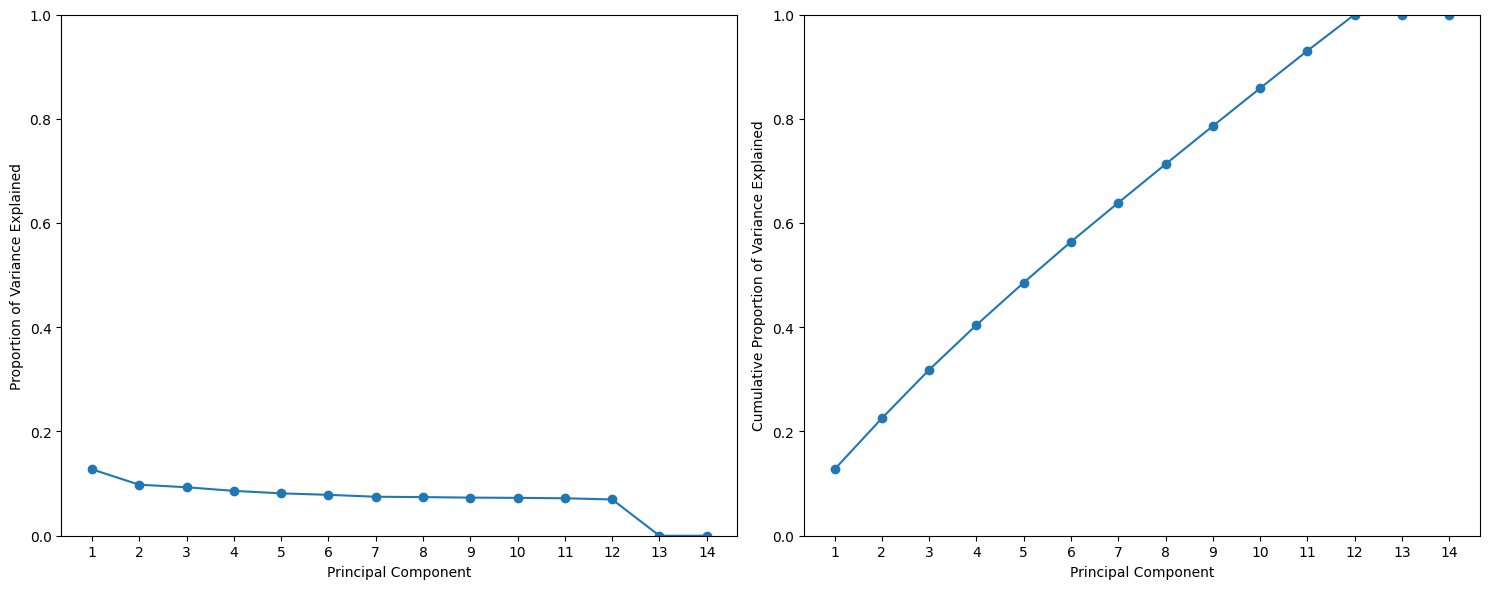

In [273]:
# Scree plot
pcaFull = PCA()
pcaFull.fit(scaled)

ticks = np.arange(pcaFull.n_components_) + 1
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax = axes[0]
ax.plot(ticks, pcaFull.explained_variance_ratio_, marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)

ax = axes[1]
ax.plot(ticks, pcaFull.explained_variance_ratio_.cumsum(), marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)

plt.tight_layout()
plt.show()

In [274]:
variance_table = pd.DataFrame({
    'PC': [f'PC{i}' for i in ticks],
    'Variance Explained (%)': (pcaFull.explained_variance_ratio_ * 100).round(2),
    'Cumulative (%)': (pcaFull.explained_variance_ratio_.cumsum() * 100).round(2)
})
print(variance_table)

      PC  Variance Explained (%)  Cumulative (%)
0    PC1                   12.73           12.73
1    PC2                    9.79           22.52
2    PC3                    9.30           31.82
3    PC4                    8.60           40.42
4    PC5                    8.13           48.55
5    PC6                    7.85           56.39
6    PC7                    7.48           63.88
7    PC8                    7.41           71.28
8    PC9                    7.31           78.59
9   PC10                    7.26           85.86
10  PC11                    7.18           93.04
11  PC12                    6.96          100.00
12  PC13                    0.00          100.00
13  PC14                    0.00          100.00


12.38% of the variance can be explained by PC1 and 11.38% of the variance can be explained by PC2. The two first principal components do not provide the best visualizations of the biplot, as they explain less than 30% of the variance together. If our threshold is 80%, I suggest using 10 PCA components, and if the threshold is 90% , 11 components should be utilized.

#Part 2. Principal components with missing values


##I. Using the dataset from Part 1, manually create some missing values so that you can compare the imputed values with the true values. Provide a hypothetical scenario of missing values under your project context. Explain how the missing values were created and justify the number or percentage of missing values used.

Creating a matrix

In [275]:
X = scaled.values  # convert df to numpy array
U, D, V = np.linalg.svd(X, full_matrices=False)
U.shape, D.shape, V.shape
pcaUS.components_
(U * D[None,:])[:3]
scores[:3]



array([[-1.46068184e+00, -2.53422622e-01,  1.77654033e+00,
         1.13340248e-01, -2.03289247e+00,  5.08881125e+00,
        -3.41952799e+00, -9.61236385e-01, -1.81614363e+00,
         2.71026714e-01, -2.58614660e+00,  4.64354975e-01,
         5.30287657e-15, -4.63060510e-15],
       [-1.99448583e+00,  3.06404115e-01, -2.42836162e-01,
        -2.19980347e+00,  2.04683933e+00, -2.76113797e-01,
        -7.60837203e-01, -4.10750858e-01,  1.32734973e-01,
        -2.73476433e-01,  2.77905480e-01,  5.85351672e-01,
        -2.09780475e-15,  1.16995815e-16],
       [ 9.24133738e-01,  3.73600763e-01,  1.98146314e+00,
         1.37699532e-01, -2.83471355e-01, -9.81988312e-01,
         1.34887246e-02, -6.09952202e-02,  1.48444973e-04,
        -2.00351158e-02,  5.15365649e-02, -2.81946389e-01,
         2.18051095e-16,  2.83529269e-16]])

In [276]:
pcaUS.components_

array([[-1.60523181e-02, -4.02934170e-02, -5.54460908e-02,
         3.93034465e-02,  1.79870603e-02,  6.46826892e-02,
        -2.87284071e-02, -2.34045126e-02, -3.81886353e-03,
        -4.17023874e-02, -2.33180467e-01, -6.05371486e-01,
         7.37440936e-01, -1.45597678e-01],
       [ 2.33113996e-02,  1.31518007e-01,  2.44520982e-02,
        -7.75603495e-01,  1.32926018e-02,  6.07468201e-01,
         6.61368661e-02,  6.25927379e-03,  1.44108859e-02,
         1.33386028e-02, -1.01661938e-03,  2.60399053e-02,
         7.58739581e-03, -7.26020851e-02],
       [ 4.38734958e-02,  7.52706587e-01,  8.63492785e-03,
        -2.83763873e-01,  5.71625805e-02, -4.93243464e-01,
         7.41590792e-03,  4.45624549e-02,  1.05897535e-02,
         6.14303479e-02, -5.88184800e-02, -1.28907169e-01,
         3.53596112e-02,  2.77670893e-01],
       [-1.11671837e-01,  1.32445986e-01, -1.72398002e-01,
         1.20337014e-01, -2.35106724e-02,  2.30413630e-01,
        -4.16058535e-01,  1.05908969e-01, -4.

In [277]:
(U * D[None,:])[:3]

array([[ 1.46068184e+00, -2.53422622e-01,  1.77654033e+00,
        -1.13340248e-01,  2.03289247e+00,  5.08881125e+00,
        -3.41952799e+00,  9.61236385e-01, -1.81614363e+00,
        -2.71026714e-01, -2.58614660e+00, -4.64354975e-01,
         1.99354815e-14, -1.71473923e-14],
       [ 1.99448583e+00,  3.06404115e-01, -2.42836162e-01,
         2.19980347e+00, -2.04683933e+00, -2.76113797e-01,
        -7.60837203e-01,  4.10750858e-01,  1.32734973e-01,
         2.73476433e-01,  2.77905480e-01, -5.85351672e-01,
        -5.24892063e-14, -6.36312284e-14],
       [-9.24133738e-01,  3.73600763e-01,  1.98146314e+00,
        -1.37699532e-01,  2.83471355e-01, -9.81988312e-01,
         1.34887246e-02,  6.09952202e-02,  1.48444973e-04,
         2.00351158e-02,  5.15365649e-02,  2.81946389e-01,
         9.24493631e-15,  8.16395853e-15]])

In [278]:
scores[:3]

array([[-1.46068184e+00, -2.53422622e-01,  1.77654033e+00,
         1.13340248e-01, -2.03289247e+00,  5.08881125e+00,
        -3.41952799e+00, -9.61236385e-01, -1.81614363e+00,
         2.71026714e-01, -2.58614660e+00,  4.64354975e-01,
         5.30287657e-15, -4.63060510e-15],
       [-1.99448583e+00,  3.06404115e-01, -2.42836162e-01,
        -2.19980347e+00,  2.04683933e+00, -2.76113797e-01,
        -7.60837203e-01, -4.10750858e-01,  1.32734973e-01,
        -2.73476433e-01,  2.77905480e-01,  5.85351672e-01,
        -2.09780475e-15,  1.16995815e-16],
       [ 9.24133738e-01,  3.73600763e-01,  1.98146314e+00,
         1.37699532e-01, -2.83471355e-01, -9.81988312e-01,
         1.34887246e-02, -6.09952202e-02,  1.48444973e-04,
        -2.00351158e-02,  5.15365649e-02, -2.81946389e-01,
         2.18051095e-16,  2.83529269e-16]])

In [279]:
print(len(clean_3))

2260


In [280]:
# Create missing values
n_omit = 50
np.random.seed(15)
r_idx = np.random.choice(np.arange(X.shape[0]),
                         n_omit,
                         replace=False)
c_idx = np.random.choice(np.arange(X.shape[1]),
                         n_omit,
                         replace=True)

# Create Xna: copy of X with selected entries set to NaN
Xna = X.copy()
Xna[r_idx, c_idx] = np.nan

In a hypothetical scenario, there may be missing data for details on Data Scientist roles as people may choose not to share some details. I chose to omit 50 values, which equates to about 2% of values missing out of 2260. This feels like a realistic estimate for missing values that can appear with financial data, somewhat sparse but not incredibly impactful. n_omit = 50 was used to remove random rows and columns of the scaled matrix

## II. Apply PCA-based imputation using different numbers of principal components, M.

In [281]:
def low_rank(X, M=1):
    U, D, V = np.linalg.svd(X, full_matrices=False)
    L = U[:,:M] * D[None,:M]
    return L.dot(V[:M])

correlations = []

for M in range(1, 16): #Trying through M 15
    Xhat = Xna.copy()
    Xbar = np.nanmean(Xhat, axis=0)
    Xhat[r_idx, c_idx] = Xbar[c_idx]

    thresh = 1e-7
    rel_err = 1
    count = 0
    ismiss = np.isnan(Xna)
    mssold = np.mean(Xhat[~ismiss]**2)
    mss0 = np.mean(Xna[~ismiss]**2)

    while rel_err > thresh:
        count += 1
        # Step 2(a)
        Xapp = low_rank(Xhat, M=M)
        # Step 2(b)
        Xhat[ismiss] = Xapp[ismiss]
        # Step 2(c)
        mss = np.mean(((Xna - Xapp)[~ismiss])**2)
        rel_err = (mssold - mss) / mss0
        mssold = mss
        print("M:{0}, Iteration: {1}, MSS:{2:.3f}, Rel.Err {3:.2e}"
              .format(M, count, mss, rel_err))


    corr = np.corrcoef(Xapp[r_idx, c_idx], X[r_idx, c_idx])[0,1]
    correlations.append({'M': M, 'Correlation': round(corr, 3)})
    print(f"M={M}: Correlation = {corr:.3f}")

corr_df = pd.DataFrame(correlations)
print("\nBest M:", corr_df.loc[corr_df['Correlation'].idxmax(), 'M'])

M:1, Iteration: 1, MSS:0.874, Rel.Err 1.27e-01
M:1, Iteration: 2, MSS:0.874, Rel.Err 4.67e-05
M:1, Iteration: 3, MSS:0.874, Rel.Err 1.03e-05
M:1, Iteration: 4, MSS:0.874, Rel.Err 2.64e-06
M:1, Iteration: 5, MSS:0.874, Rel.Err 7.35e-07
M:1, Iteration: 6, MSS:0.874, Rel.Err 2.16e-07
M:1, Iteration: 7, MSS:0.874, Rel.Err 6.50e-08
M=1: Correlation = 0.378
M:2, Iteration: 1, MSS:0.776, Rel.Err 2.25e-01
M:2, Iteration: 2, MSS:0.776, Rel.Err 1.43e-04
M:2, Iteration: 3, MSS:0.776, Rel.Err 3.92e-05
M:2, Iteration: 4, MSS:0.776, Rel.Err 1.21e-05
M:2, Iteration: 5, MSS:0.776, Rel.Err 4.02e-06
M:2, Iteration: 6, MSS:0.776, Rel.Err 1.40e-06
M:2, Iteration: 7, MSS:0.776, Rel.Err 5.00e-07
M:2, Iteration: 8, MSS:0.776, Rel.Err 1.83e-07
M:2, Iteration: 9, MSS:0.776, Rel.Err 6.77e-08
M=2: Correlation = 0.336
M:3, Iteration: 1, MSS:0.683, Rel.Err 3.18e-01
M:3, Iteration: 2, MSS:0.683, Rel.Err 1.62e-04
M:3, Iteration: 3, MSS:0.682, Rel.Err 5.66e-05
M:3, Iteration: 4, MSS:0.682, Rel.Err 2.16e-05
M:3, Itera

M range 1-16 tries out 15 principal components. The longest iteration ran was for M = 10, which got up to 56 iterations before it fell below the threshold.

## III. Compute the correlation between the true and imputed values for each value of M. Analyze how the number of principal components affects imputation performance, and discuss which value of M gives the best results and whether the imputed values appear reliable in the context of your project.

In [282]:
# Summary table
corr_df = pd.DataFrame(correlations)
corr_df.columns = ['M', 'Correlation']
corr_df = corr_df.set_index('M')
print(corr_df.to_string())
print(f"\nBest M: {corr_df['Correlation'].idxmax()} with correlation {corr_df['Correlation'].max():.3f}")

    Correlation
M              
1         0.378
2         0.336
3         0.369
4         0.487
5         0.440
6         0.638
7         0.429
8         0.563
9         0.350
10        0.318
11        0.312
12        0.997
13        0.565
14       -0.497
15       -0.497

Best M: 12 with correlation 0.997


Overall, increasing the number of principal components increases the correlation. The value of M that provides the highest percentage of correlation was M = 12, with a correlation of 97.7%. This makes sense, as we learned that 100% of variance is covered by PCA 12. In the context of our problem, inputting values does make sense as we are able to generally estimate salaries and such based off of other known values.